In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
os.makedirs("charts", exist_ok=True)

In [3]:
df = pd.read_csv("../data/processed/merged_restaurant_data.csv")

In [4]:
print(df.shape)
df.head()

(9227, 7)


,name,city,province,latitude,longitude,state_name,population
0,Wendy's,Washington Court House,OH,39.53255,-83.44526,Ohio,14439
1,Frisch's Big Boy,Maysville,KY,38.62736,-83.79141,Kentucky,8737
2,OMG! Rotisserie,Athens,OH,39.35155,-82.09728,Ohio,23396
3,Domino's Pizza,Hamilton,OH,39.41760,-84.47641,Ohio,63468
4,Domino's Pizza,Englewood,OH,39.86969,-84.29358,Ohio,13356


In [5]:
city_counts = (
    df.groupby(["city", "state_name"])
      .agg(
          restaurant_count=("name", "count"),
          population=("population", "first")
      )
      .reset_index()
)

city_counts.head()

,city,state_name,restaurant_count,population
0,Abbeville,Louisiana,2,11003
1,Aberdeen,Maryland,1,17298
2,Aberdeen,North Carolina,1,9228
3,Aberdeen,South Dakota,10,28189
4,Aberdeen,Washington,6,17088


In [6]:
major_cities = city_counts[
    city_counts["population"] >= 500000
].copy()

print("Major cities:", len(major_cities))

Major cities: 83


In [7]:
major_cities["restaurants_per_100k"] = (
    major_cities["restaurant_count"]
    /
    major_cities["population"]
) * 100000

major_cities.head()

,city,state_name,restaurant_count,population,restaurants_per_100k
17,Akron,Ohio,5,537241,0.930681
24,Albany,New York,4,607238,0.658720
30,Albuquerque,New Mexico,35,765360,4.573011
44,Allentown,Pennsylvania,2,644758,0.310194
118,Atlanta,Georgia,38,5298788,0.717145


In [8]:
top10 = (
    major_cities
    .sort_values(
        "restaurants_per_100k",
        ascending=False
    )
    .head(10)
)

top10

,city,state_name,restaurant_count,population,restaurants_per_100k
522,Cincinnati,Ohio,119,1726642,6.891990
30,Albuquerque,New Mexico,35,765360,4.573011
2034,Ogden,Utah,26,630643,4.122776
2038,Oklahoma City,Oklahoma,41,1017828,4.028186
582,Columbia,South Carolina,22,610536,3.603391
687,Dayton,Ohio,23,672634,3.419393
1396,Knoxville,Tennessee,21,627090,3.348802
1750,Mesa,Arizona,17,511764,3.321844
1593,Louisville,Kentucky,30,988018,3.036382
2797,Tulsa,Oklahoma,22,747529,2.943030


In [9]:
bottom10 = (
    major_cities
    .sort_values(
        "restaurants_per_100k",
        ascending=True
    )
    .head(10)
)

bottom10

,city,state_name,restaurant_count,population,restaurants_per_100k
2465,San Francisco,California,3,3417736,0.087777
408,Cape Coral,Florida,1,675797,0.147973
1801,Mission Viejo,California,1,647990,0.154323
1943,New York,New York,36,19268388,0.186835
593,Concord,California,1,531305,0.188216
295,Boston,Massachusetts,9,4453352,0.202095
321,Bridgeport,Connecticut,2,945974,0.211422
358,Buffalo,New York,2,934832,0.213942
2369,Riverside,California,5,2333040,0.214313
166,Baltimore,Maryland,6,2201673,0.272520


In [12]:
top10.to_csv(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question5_top10.csv",
    index=False
)

bottom10.to_csv(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question5_bottom10.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


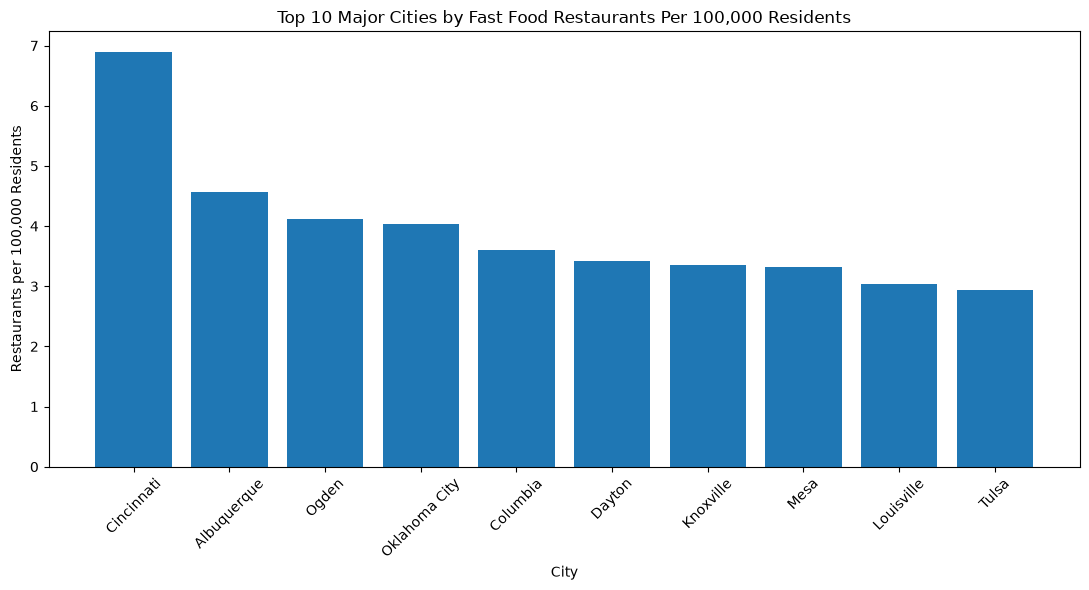

In [13]:
plt.figure(figsize=(11,6))

plt.bar(
    top10["city"],
    top10["restaurants_per_100k"]
)

plt.title(
    "Top 10 Major Cities by Fast Food Restaurants Per 100,000 Residents"
)

plt.xlabel("City")
plt.ylabel("Restaurants per 100,000 Residents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question5_top10.png",
    dpi=300
)

plt.show()

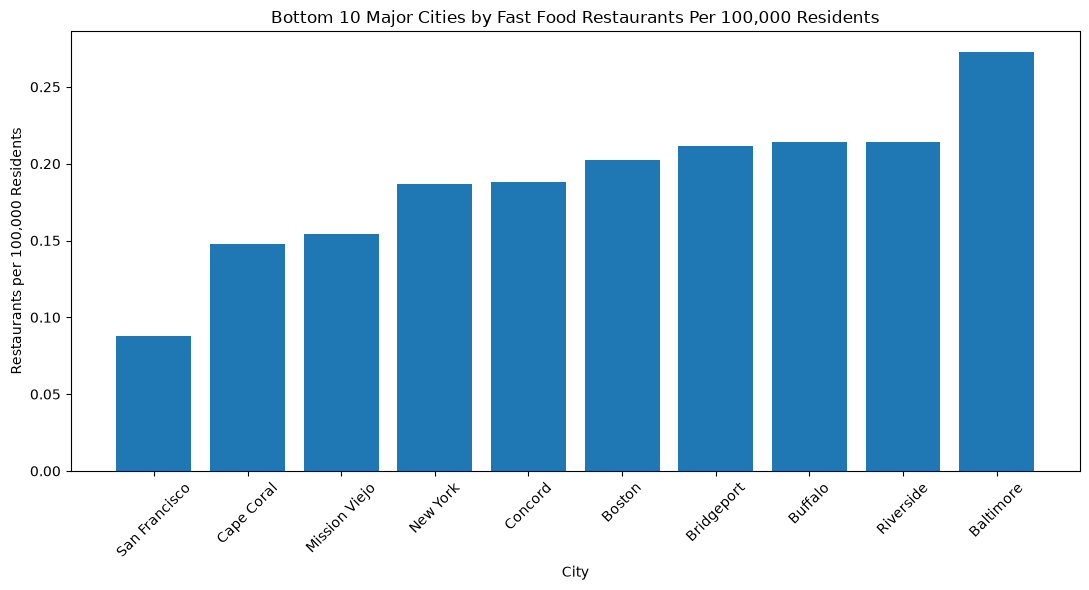

In [14]:
plt.figure(figsize=(11,6))

plt.bar(
    bottom10["city"],
    bottom10["restaurants_per_100k"]
)

plt.title(
    "Bottom 10 Major Cities by Fast Food Restaurants Per 100,000 Residents"
)

plt.xlabel("City")
plt.ylabel("Restaurants per 100,000 Residents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question5_bottom10.png",
    dpi=300
)

plt.show()